# 05 · Your own soil

Compare Gainesville maize grain yield on a soil profile supplied as a CSV and on a shallower version of that profile.

## You will learn

- Prepare soil data in the columns of `write_soil_template()`.
- Check soil layers and summarize depth and extractable water.
- Run the same treatment on two soil depths and compare grain yield (`HWAM`).

In [1]:
LESSON = "05_own_soil"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load tools for soil tables and inline plots.

In [3]:
# Load tools for soil tables and inline plots.
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Create a soil template in `runs/` and inspect its example layers ([soil guide](../../docs/guide/soil.md)).

In [4]:
# Create an example soil template.
template_path = RUNS / "soil_template.csv"
dl.write_soil_template(template_path)
template = pd.read_csv(template_path)
template[["soil_id", "slb", "slll", "sdul", "ssat", "srgf"]]

,soil_id,slb,slll,sdul,ssat,srgf
0,IBMZ910214,5,0.10,0.24,0.45,1.0
1,IBMZ910214,15,0.12,0.26,0.43,0.8
2,IBMZ910214,30,0.13,0.27,0.40,0.6


🐍 Python idea  
The template is a CSV: one row per layer, with profile values repeated on every row.
Its three example layers are a starting shape, not the Gainesville soil used below.

Read the supplied Millhopper Fine Sand CSV and show its water limits and root growth factors.

In [5]:
# Read the Gainesville soil data copied into runs.
soil = pd.read_csv(RUNS / "gainesville_soil.csv")
soil[["soil_id", "slb", "slll", "sdul", "ssat", "srgf"]]

,soil_id,slb,slll,sdul,ssat,srgf
0,IBMZ910014,5,0.026,0.096,0.23,1.000
1,IBMZ910014,15,0.025,0.086,0.23,1.000
2,IBMZ910014,30,0.025,0.086,0.23,0.700
3,IBMZ910014,60,0.025,0.086,0.23,0.300
4,IBMZ910014,90,0.028,0.090,0.23,0.050
5,IBMZ910014,120,0.028,0.090,0.23,0.030
6,IBMZ910014,150,0.029,0.130,0.23,0.002
7,IBMZ910014,180,0.070,0.258,0.36,0.000


🌱 Crop idea  
`slb` is the layer bottom in cm; `slll`, `sdul` and `ssat` are water contents in cm³/cm³ (lower limit, drained upper limit and saturation).
`srgf` is the root growth factor (0–1); `-99` in optional columns means not given.

Summarize the full profile to measure its depth and water between the lower and drained upper limits.

In [6]:
# Summarize the supplied soil profile in centimetres and millimetres.
full_soil_summary = dl.summarize_soil(soil)
pd.DataFrame([{
    "Soil profile": full_soil_summary["soil_id"],
    "Layers": full_soil_summary["layers"],
    "Depth (cm)": full_soil_summary["depth"],
    "Extractable water (mm)": full_soil_summary["extractable_water"],
}])

,Soil profile,Layers,Depth (cm),Extractable water (mm)
0,IBMZ910014,8,180.0,160.95


🌱 Crop idea  
Extractable water sums `(sdul - slll) × layer thickness` over the profile, with cm of water converted to mm.
It describes storage capacity between these limits, not the soil's water content on planting day.

Check treatment 1 with the supplied weather and soil data before running DSSAT.

In [7]:
# Check the FileX, the 1982 weather CSV and the matching soil profile.
inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "station_weather.csv",
    "executable": dssat,
    "treatment": 1,
}
sim = dl.Simulation(**inputs, soil=soil)
problems = sim.check(verbose=False)
print("Problems:", problems)

Problems: []


The FileX uses McCurdy 84aa (`IB0035`), planted on 26 February 1982, with water and nitrogen simulation on.
Treatment 1 is named RAINFED LOW NITROGEN, but its stock schedule includes 13 mm of irrigation on 4 March; we keep that management unchanged.

Try an invalid water limit in a separate copy to see how the checks explain a soil-data problem.

In [8]:
# Check a deliberately invalid copy without changing the working soil data.
bad_soil = soil.copy()
bad_soil.loc[0, "sdul"] = bad_soil.loc[0, "slll"]
bad_sim = dl.Simulation(**inputs, soil=bad_soil)
bad_problems = bad_sim.check(verbose=False)
print("\n".join(bad_problems))

Soil data row 2: slll 0.026, sdul 0.026, ssat 0.23 are not in strict order. Correct the fractions so slll < sdul < ssat (equal values leave no plant-available water or no pore space).


🐍 Python idea  
`.copy()` lets us change a table without changing `soil`; `.loc[0, "sdul"]` selects the first row's drained upper limit.
Use `0 < slll < sdul < ssat < 1` and increasing layer depths; `Problems: []` means no problems were found. Soil checks count the header as row 1, so the message's row 2 is DataFrame index 0.

Run the checked full profile and read the treatment's grain yield (`HWAM`, kg/ha).

In [9]:
# Run the full profile and show grain yield and development dates.
full_result = sim.run()
full_summary = dl.to_dataframe(dl.read_summary(full_result.run_dir))
full_summary[["TRNO", "TNAM", "HWAM", "ADAT", "MDAT"]]

,TRNO,TNAM,HWAM,ADAT,MDAT
0,1,RAINFED LOW NITROGEN,2293,1982-05-13,1982-07-04


Inspect the successful run's warnings to see DSSAT's assumptions about the stock soil and its low-radiation day.

In [10]:
# Show the compact run result and its DSSAT warning blocks.
print(full_result)
for warning in full_result.warnings:
    print(warning)

RunResult(returncode=0, run_dir='dssat_run_2026-10-06_233133', 28 output files, 3 warnings)
IPSOIL  YEAR DOY =    0   0
Saturated hydraulic conductivity equal to zero for one or more soil layers.
Data will be treated as missing.
SOILDYN  YEAR DOY = 1982  56
Soil photosynthesis factor (SLPF) = 0.92
IPWTH   YEAR DOY = 1982  98
UFGA8201.WTH
Line      103
SRAD =   0.80 MJ.m-2.d-1


DSSAT treats zero saturated hydraulic conductivity as missing, reports `SLPF = 0.92`, and flags solar radiation of 0.80 MJ/m²/day on day 98 of 1982.
These warnings accompany complete results; inspect them when interpreting the comparison.

Keep only the layers ending at or above 60 cm, then run the same inputs and compare soil storage and yield.

In [11]:
# Run a shallower profile with the same upper-layer values and management.
shallow_depth_cm = 60
shallow_soil = soil.loc[soil["slb"] <= shallow_depth_cm].copy()
shallow_soil_summary = dl.summarize_soil(shallow_soil)
shallow_sim = dl.Simulation(**inputs, soil=shallow_soil)
shallow_result = shallow_sim.run()
shallow_yield = dl.read_summary(shallow_result.run_dir)[0]["HWAM"]
full_yield = full_summary.loc[0, "HWAM"]
comparison = pd.DataFrame([
    {"Profile": "Full", "Depth (cm)": full_soil_summary["depth"],
     "Extractable water (mm)": full_soil_summary["extractable_water"],
     "HWAM (kg/ha)": full_yield, "Change from full (kg/ha)": 0},
    {"Profile": "Shallow", "Depth (cm)": shallow_soil_summary["depth"],
     "Extractable water (mm)": shallow_soil_summary["extractable_water"],
     "HWAM (kg/ha)": shallow_yield, "Change from full (kg/ha)": shallow_yield - full_yield},
])
comparison

,Profile,Depth (cm),Extractable water (mm),HWAM (kg/ha),Change from full (kg/ha)
0,Full,180.0,160.95,2293,0
1,Shallow,60.0,37.05,1480,-813


This comparison removes whole lower layers and keeps the upper layers' properties and soil ID.
The copied FileX's initial conditions extend to 180 cm; dssatlab permits them with a shallower profile, and DSSAT runs on the supplied layers.
The 60 cm profile yields 1,480 kg/ha versus 2,293 kg/ha at 180 cm, a decrease of 813 kg/ha.

Plot both yields on a common scale to see the response to the shallower profile.

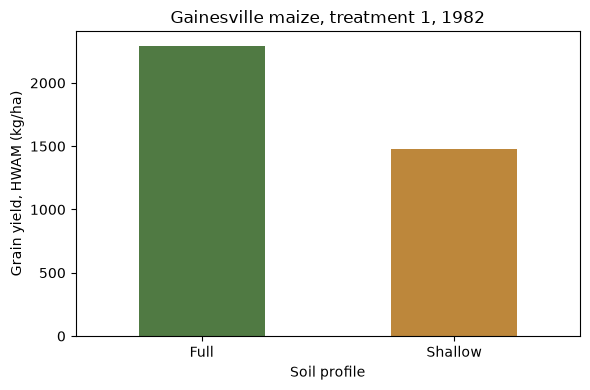

In [12]:
# Plot grain yield for the full and shallow soil profiles.
ax = comparison.plot.bar(x="Profile", y="HWAM (kg/ha)", legend=False,
                         rot=0, figsize=(6, 4), color=["#507a43", "#bd873b"])
ax.set(xlabel="Soil profile", ylabel="Grain yield, HWAM (kg/ha)",
       title="Gainesville maize, treatment 1, 1982")
plt.tight_layout()
plt.show()

🌱 Crop idea  
Compare both storage capacity and yield: less extractable water does not by itself prove the cause of a yield change.
Removing layers also changes root access and the soil's nutrient pools; this is one treatment in one weather year.

## Your turn

Choose another layer-bottom depth and compare it with the full profile using the same treatment and weather.

Hint: edit `chosen_depth_cm = 90` to 30, 60, 90, 120 or 150, then run this cell.

In [13]:
# Rebuild both simulations and compare a chosen depth with the full profile.
chosen_depth_cm = 90
exercise_soil = pd.read_csv(RUNS / "gainesville_soil.csv")
exercise_inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "station_weather.csv",
    "executable": dssat,
    "treatment": 1,
}
exercise_chosen = exercise_soil.loc[exercise_soil["slb"] <= chosen_depth_cm].copy()
exercise_rows = []
for label, profile in [("Full", exercise_soil), ("Chosen", exercise_chosen)]:
    profile_summary = dl.summarize_soil(profile)
    exercise_sim = dl.Simulation(**exercise_inputs, soil=profile)
    exercise_result = exercise_sim.run()
    exercise_yield = dl.read_summary(exercise_result.run_dir)[0]["HWAM"]
    exercise_rows.append({
        "Profile": label, "Depth (cm)": profile_summary["depth"],
        "Extractable water (mm)": profile_summary["extractable_water"],
        "HWAM (kg/ha)": exercise_yield,
    })
exercise_comparison = pd.DataFrame(exercise_rows)
exercise_comparison["Change from full (kg/ha)"] = (
    exercise_comparison["HWAM (kg/ha)"] - exercise_comparison.loc[0, "HWAM (kg/ha)"]
)
exercise_comparison

,Profile,Depth (cm),Extractable water (mm),HWAM (kg/ha),Change from full (kg/ha)
0,Full,180.0,160.95,2293,0
1,Chosen,90.0,55.65,2274,-19


🌱 Crop idea  
At the default 90 cm, storage falls from 160.95 to 55.65 mm, yet yield falls by only 19 kg/ha (2,293 to 2,274 kg/ha).
That small yield response may look surprising: total storage and yield do not change in proportion in this case.

## Recap

- Soil data has one row per layer, increasing bottom depths and repeated profile values.
- `check()` explains problems; `summarize_soil()` reports depth in cm and extractable water in mm.
- Supplying `soil=` makes DSSAT use that profile, so two otherwise matching runs can compare `HWAM` in kg/ha.

Next: [06 · An experiment from scratch](../06_experiment_from_scratch/lesson.ipynb).